##### Tensorflow // Keras
- Tensorflow is a deep learning framework created by Google
- Its a toolbox for building neural networks
- It helps the computer do math with large amounts of data
- It is optmised for training models fast

###### Why ??
- It is powerful and fast
- It can run on laptops, severs and phones
- It is used real applications as well - Google Search, You Tube

###### Keras  - User friendly front-end of Tensorflow
- Tensorflow  - Its is powerful but complex
- KERAS - SIMPLE AND EASY USER INTERFACE

- If you use Keras it will use tensorflow underneath.
- Tensorflow = Engine
- Keras - Steering Wheel

###### Keras also gives you simple functions like  -
- 1. sequential() -  for creating the Model
- 2. Dense() - add a layer
- 3. model.compile() - Choose Optmisation function & Loss
- 4. Model.fit() - train the model
-    **Layers, Activation Function, Optmizer, Loss, Epochs, Batch Size**

###### Dense(16) ----> Add a layer with 16 neurons
- Why do we use multiple layers ?
- More layers = the model can learn more complex patterns

###### Read Dataset

In [12]:
import pandas as pd
import os
os.getcwd()

'C:\\Users\\pmgho\\OneDrive\\Documents\\ML Capstone Project'

In [13]:
os.chdir('C:\\Users\\pmgho\\OneDrive\\Documents\\ML Capstone Project\\')

In [14]:
data = pd.read_csv('dataset.csv')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [15]:
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [19]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
! pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [20]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

##### Splitting the Data in X and Y for the model

In [21]:
X = data.drop('target',axis=1)
y = data['target']

In [22]:
display(X)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


##### Sampling the data for training and Validation

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


##### Feature Engineering - Normalising the features - Computation becomes proper

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [37]:
X_train_scaled

array([[-1.35679832,  0.72250438,  0.00809909, ...,  0.95390513,
        -0.68970073, -0.50904773],
       [ 0.38508599,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [-0.92132724,  0.72250438,  0.98808912, ..., -0.69498803,
        -0.68970073, -0.50904773],
       ...,
       [ 1.58263146,  0.72250438,  1.96807914, ..., -0.69498803,
         0.32186034, -0.50904773],
       [-0.92132724,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [ 0.92942484, -1.38407465,  0.00809909, ...,  0.95390513,
         1.33342142, -0.50904773]])

In [38]:
X_test_scaled

array([[ 3.51938054e-01,  5.20416500e-01, -8.17224232e-01,
         6.92350698e-01,  6.70698758e-01, -5.45776823e-01,
        -8.61891607e-01, -1.43822060e+00,  1.28536917e+00,
        -3.99335669e-01, -4.85744493e-01,  7.31507170e-02,
        -2.00597821e+00],
       [ 5.85288285e-01,  5.20416500e-01,  2.00451227e+00,
         1.72875297e+00,  9.21953360e-01, -5.45776823e-01,
        -8.61891607e-01,  4.50638062e-01, -7.77986605e-01,
        -6.92823330e-01, -4.85744493e-01, -8.19288030e-01,
         9.42568077e-01],
       [ 3.51938054e-01,  5.20416500e-01,  1.06393343e+00,
         6.92350698e-01, -2.46998376e+00,  1.83225076e+00,
         1.16023870e+00,  1.01327681e+00, -7.77986605e-01,
        -6.92823330e-01,  1.07375098e+00,  7.31507170e-02,
         9.42568077e-01],
       [ 2.35262938e-01, -1.92153785e+00, -8.17224232e-01,
        -1.36771119e-01,  3.45543726e+00, -5.45776823e-01,
        -8.61891607e-01,  8.89417229e-02,  1.28536917e+00,
         5.54499228e-01, -4.85744493e

##### Building Neural Networks - 3 Layers Dense Network

In [39]:
model = keras.Sequential([
    layers.Dense(32,activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dense(16,activation='relu'),
    layers.Dense(8,activation='relu'),
    layers.Dense(1,activation='sigmoid') # Binary Class Prediction
    
])

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### Compile The Model

In [40]:
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',metrics=['accuracy'])

##### Training the Model -

In [41]:
history = model.fit(X_train_scaled,y_train,
                    validation_split=0.2,epochs = 50,verbose = 1)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.4715 - loss: 0.7215 - val_accuracy: 0.4082 - val_loss: 0.7023
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4870 - loss: 0.6873 - val_accuracy: 0.4082 - val_loss: 0.6709
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5181 - loss: 0.6617 - val_accuracy: 0.5510 - val_loss: 0.6461
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5803 - loss: 0.6439 - val_accuracy: 0.5714 - val_loss: 0.6281
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6321 - loss: 0.6292 - val_accuracy: 0.5918 - val_loss: 0.6154
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6736 - loss: 0.6161 - val_accuracy: 0.6735 - val_loss: 0.6034
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7202 - loss: 0.6023 - val_accuracy: 0.6735 - val_loss: 0.5919
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7461 - loss: 0.5892 - val_accuracy: 0.7143 - val_loss: 0.5826


In [42]:
loss, accuracy = model.evaluate(X_test_scaled,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8852 - loss: 0.3779


In [43]:
print("The accuracy of the Model - ",accuracy)

The accuracy of the Model -  0.8852459192276001


In [44]:
pred = model.predict(X_test_scaled)
pred

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


array([[3.8595176e-01],
       [7.2123897e-01],
       [9.1787475e-01],
       [4.4954486e-02],
       [9.5963883e-01],
       [8.9676285e-01],
       [9.6133381e-01],
       [2.1025273e-03],
       [2.4225740e-02],
       [6.3004613e-01],
       [8.4262353e-01],
       [4.7000848e-02],
       [8.8851279e-01],
       [2.6421120e-02],
       [9.9215382e-01],
       [9.5492524e-01],
       [9.9557102e-01],
       [8.4190205e-02],
       [1.1574728e-02],
       [2.9872462e-02],
       [6.2692559e-01],
       [4.7345102e-02],
       [3.8166291e-01],
       [8.9434445e-01],
       [9.7975773e-01],
       [9.3047768e-01],
       [8.2108301e-01],
       [7.4597108e-01],
       [5.9730086e-02],
       [9.7901762e-01],
       [3.8817182e-02],
       [4.3190330e-02],
       [1.3827527e-02],
       [1.3278075e-01],
       [8.9958096e-01],
       [4.0410694e-02],
       [8.5642868e-01],
       [9.0811807e-01],
       [8.6407578e-01],
       [9.2549098e-01],
       [7.0074368e-01],
       [7.994401

##### Loss Function
- Tells the model how wrong it is during training

##### Adjust Weights
- **OPtimisers**  - ***decides how the model learns by adjusting the weights***
- **adam** - ***most efficient, fast and best to be used***

- **An epoch** = ***one full pass through the training data***
- **More epochs** = ***more learning***
- **Too many epochs** = ***overfit the model as well***

In [45]:
import matplotlib.pyplot as plt

In [46]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


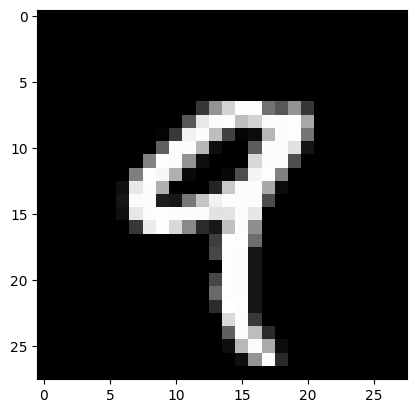

In [47]:
plt.imshow(X_train[4],cmap = 'gray')
plt.show()

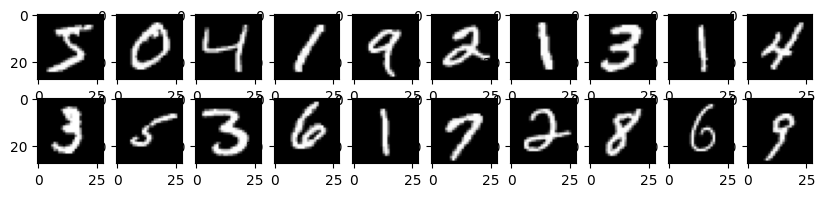

In [48]:
plt.figure(figsize=(10,2))
for i in range(20):
  plt.subplot(2,10,i+1) ## nrows, ncols, index
  plt.imshow(X_train[i],cmap = 'gray')

plt.show()

##### Preprocess of the data

In [52]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [50]:
print(X_train.shape)

(60000, 28, 28)


In [53]:
28*28

784

In [54]:
X_train = X_train.reshape(-1,784).astype('float') / 255
X_test = X_test.reshape(-1,784).astype('float') / 255

In [55]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [56]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

- Originally MNIST pixwl values are orginally stored as integer (0-255)
- Pixel values goes from 0 to 255
- -1 numpy to reshape - Calculate the dimesions automatically based on the data
- and it reshape by itself

In [57]:
model = keras.Sequential([
    layers.Dense(128, activation='relu',input_shape = (X_train.shape[1],)),
    layers.Dense(64,activation = 'relu'),
    layers.Dense(10,activation='softmax')  ### Multi-class
])

In [58]:
model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy'
,metrics = ['accuracy'])

In [59]:
model.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9303 - loss: 0.2410
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9703 - loss: 0.1005
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9794 - loss: 0.0683
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0527
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9864 - loss: 0.0421


In [60]:
test_loss, test_acc = model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.0913


In [61]:
test_acc

0.9760000109672546

In [62]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


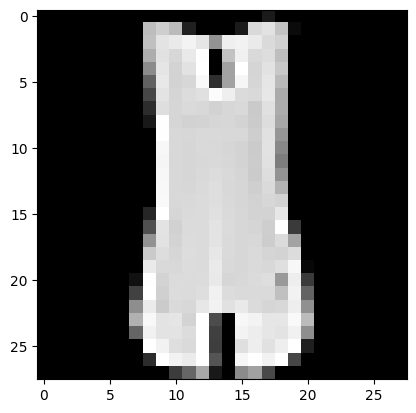

In [63]:
plt.imshow(X_train[4],cmap = 'gray')
plt.show()

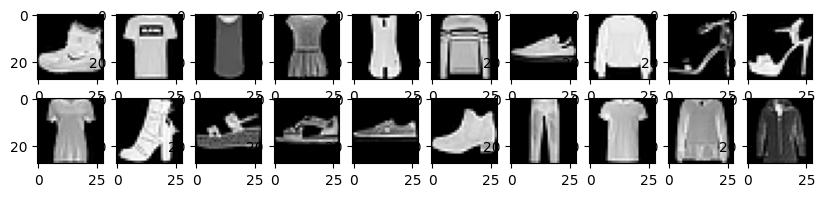

In [64]:
plt.figure(figsize=(10,2))
for i in range(20):
  plt.subplot(2,10,i+1) ## nrows, ncols, index
  plt.imshow(X_train[i],cmap = 'gray')

plt.show()

In [65]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [66]:
X_train.shape

(60000, 28, 28)

##### **NLP** - Fundamentals to build GEN AI Models
- NLP is a field of AI focused on enbling computers to understand, interpret,
- generate and interact with human language

##### It combines linguistics, computer science and machine learning to process,
##### text or speech

- 1. Text processing  -
  - Tokenisation
  - Lemmatisation and Stemming
  - Removing Stop  - frequent occuring words

#### Tokensisation - splitting text into smaller units


In [67]:
s = 'NLP is called as Natural Language Processing'
print(s)
k = s.split()  ### string method
print("Word Tokenisation --- ")
print(k)

NLP is called as Natural Language Processing
Word Tokenisation --- 
['NLP', 'is', 'called', 'as', 'Natural', 'Language', 'Processing']


##### NLTK  = Natural Language Toolkit

In [68]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize, sent_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pmgho\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [69]:
s = 'NLP is called as Natural Language Processing'
w = word_tokenize(s)
print(w)

['NLP', 'is', 'called', 'as', 'Natural', 'Language', 'Processing']


In [70]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pmgho\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [71]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [72]:
w

['NLP', 'is', 'called', 'as', 'Natural', 'Language', 'Processing']

In [73]:
filtered_words = [i for i in w if i.lower() not in stop_words]
filtered_words

['NLP', 'called', 'Natural', 'Language', 'Processing']